**Goal:** build a small spam filter -- turn text messages into a bag of words, train a Naive Bayes
classifier, read off the words it found most spam-like, and reproduce one of its verdicts by hand.
Then see Laplace smoothing rescue a message from a single unseen word, and measure what the "naive"
assumption costs on correlated data. Pairs with the concept note
[Naive Bayes](l07_concept_naive_bayes.qmd).

> **Previously:** L06 -- Gaussian Discriminant Analysis  |  **Next:** L08 -- Support Vector Machines

> This page is the read-only view. To run the lab, open the notebook
> (`l07_lab_naive_bayes.ipynb`) -- in Colab via the badge on the concept page, or locally.

## Scenario

A phone carrier wants to flag spam text messages automatically. We have a labeled history of past
messages -- each marked **spam** or **ham** (the standard name for a normal, wanted message) -- and we
want a classifier that reads a new message and calls it.

The corpus below is **synthetic** (built from templates with a fixed seed, so everyone gets identical
messages and numbers). About a third of each class is drawn from deliberately *borderline* templates,
so the two vocabularies overlap the way real spam and real chat do.

## Setup

The setup is **two cells** (the pattern every lab uses). The first only installs; the second imports,
seeds the generator, and builds the corpus.

In [1]:
# Setup, cell 1 of 2 -- INSTALL (run once; Colab wipes installs when it resets on open)
# Colab already ships scikit-learn, numpy, pandas and matplotlib, so this is effectively a no-op there.
%pip install -q scikit-learn
# local, in a terminal (not in the notebook):  uv add scikit-learn numpy pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Setup, cell 2 of 2 -- IMPORTS, SEED, DATA (safe to re-run without re-installing)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(7)           # fixed seed: identical messages for everyone

spam_clear = [
    "win a free {prize} text {code} now to claim your prize",
    "congratulations you have won {amount} cash claim now",
    "urgent your account needs to verify click {link} now",
    "free {prize} offer expires today reply yes to claim",
    "you are a winner call {phone} to collect your {amount} prize",
    "limited offer get {amount} off click {link} right now",
    "claim your free {prize} now before this offer expires",
    "final notice you won {amount} text {code} to claim cash",
]
ham_clear = [
    "hey are we still on for {activity} later",
    "can you grab {object} when you get home",
    "running late will see you at {time}",
    "thanks for {favor} yesterday really appreciate it",
    "did you finish the {object} for our meeting",
    "call me when you are free after {activity}",
    "lunch at {time} sounds good see you then",
    "i left the {object} on the kitchen table",
]
# Coherent BORDERLINE messages: readable, but they lean on the other class's vocabulary.
spam_hard = [   # labeled spam, sounds chatty
    "hey did you see you won a free {prize} just call {phone} to claim it",
    "your free {activity} pass is ending today click {link} to keep it",
    "thanks for joining you won {amount} reply yes to claim your prize",
]
ham_hard = [    # labeled ham, uses spammy words innocently
    "the {activity} tickets are free call me now if you want to go",
    "i won our bet so you owe me {object} see you at {time}",
    "the office is giving away a free {prize} before friday want one",
]
prize = ["phone", "iphone", "vacation", "gift card", "laptop", "ticket"]
amount = ["1000 dollars", "500 dollars", "2000 dollars", "50 percent", "900 dollars"]
code = ["win", "claim", "yes", "prize"]
link = ["this link", "the link below", "here"]
phone = ["555 0199", "555 0123", "this number"]
activity = ["dinner", "the game", "coffee", "the gym", "class"]
obj = ["milk", "the report", "the keys", "groceries", "the notes"]
time = ["noon", "six", "seven", "half past five"]
favor = ["the ride", "helping out", "dinner", "the loan"]

def fill(t):
    return t.format(prize=rng.choice(prize), amount=rng.choice(amount),
                    code=rng.choice(code), link=rng.choice(link),
                    phone=rng.choice(phone), activity=rng.choice(activity),
                    object=rng.choice(obj), time=rng.choice(time),
                    favor=rng.choice(favor))

n_each = 90
P_HARD = 0.30                             # share of each class drawn from the borderline pool
texts, labels = [], []
for _ in range(n_each):
    pool = spam_hard if rng.random() < P_HARD else spam_clear
    texts.append(fill(rng.choice(pool))); labels.append("spam")
for _ in range(n_each):
    pool = ham_hard if rng.random() < P_HARD else ham_clear
    texts.append(fill(rng.choice(pool))); labels.append("ham")
labels = np.array(labels)

Xtr_txt, Xte_txt, ytr, yte = train_test_split(texts, labels, test_size=0.25,
                                              random_state=7, stratify=labels)
print(len(texts), "messages |", (labels == "spam").sum(), "spam /", (labels == "ham").sum(), "ham")
print("example spam:", texts[0])
print("example ham: ", texts[n_each])
print(len(Xtr_txt), "train /", len(Xte_txt), "test")

180 messages | 90 spam / 90 ham
example spam: limited offer get 2000 dollars off click here right now
example ham:  running late will see you at noon
135 train / 45 test


~~~text
180 messages | 90 spam / 90 ham
example spam: limited offer get 2000 dollars off click here right now
example ham:  running late will see you at noon
135 train / 45 test
~~~

## Step 1: Text to Numbers, Then a Classifier

A classifier cannot read words -- it needs numbers. The **bag of words** representation builds a
vocabulary from the training messages and counts how often each word appears in each message: one
feature per word, order thrown away. `CountVectorizer` does exactly that.

In [3]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

vec = CountVectorizer()
X_train = vec.fit_transform(Xtr_txt)     # learn the vocabulary on TRAIN, then count
X_test = vec.transform(Xte_txt)          # same vocabulary, applied to TEST
print("feature matrix:", X_train.shape, "(messages x vocabulary words)")

feature matrix: (135, 128) (messages x vocabulary words)


~~~text
feature matrix: (135, 128) (messages x vocabulary words)
~~~

128 word-features. Modeling the *joint* distribution over 128 columns is the combinatorial wall from
the concept note: just present-or-absent is already $2^{128}$ combinations, and tracking counts (not
mere presence) makes it far larger still. Naive Bayes walks through it by treating each word as an
independent vote. Fit it (counting only -- instant) and
score it:

In [4]:
nb = MultinomialNB().fit(X_train, ytr)
spam_idx = list(nb.classes_).index("spam")
print("class order:", nb.classes_)
print(f"MultinomialNB test accuracy: {nb.score(X_test, yte):.3f}")

class order: ['ham' 'spam']
MultinomialNB test accuracy: 1.000


~~~text
class order: ['ham' 'spam']
MultinomialNB test accuracy: 1.000
~~~

Every test message right. That is not a fluke or a bug: spam and normal chat use almost **disjoint
vocabularies**, so the words alone are nearly enough -- which is exactly why Naive Bayes dominated spam
filtering for years. Try it on three messages it has never seen:

In [5]:
new_msgs = [
    "free prize claim your cash now",
    "are we still on for coffee later",
    "call me when you get the report",
]
Xnew = vec.transform(new_msgs)
preds = nb.predict(Xnew)
probs = nb.predict_proba(Xnew)[:, spam_idx]
for msg, pred, p in zip(new_msgs, preds, probs):
    print(f"P(spam)={p:.3f}  -> {pred:<4} | {msg}")

P(spam)=1.000  -> spam | free prize claim your cash now
P(spam)=0.000  -> ham  | are we still on for coffee later
P(spam)=0.000  -> ham  | call me when you get the report


~~~text
P(spam)=1.000  -> spam | free prize claim your cash now
P(spam)=0.000  -> ham  | are we still on for coffee later
P(spam)=0.000  -> ham  | call me when you get the report
~~~

## Step 2: Open the Box -- the Words, and the Arithmetic

A Naive Bayes model is fully inspectable. `feature_log_prob_` holds $\log P(\text{word} \mid C)$ for
every word and class; the difference between the two classes ranks each word from most ham-like to most
spam-like.

In [6]:
vocab = vec.get_feature_names_out()
log_ratio = nb.feature_log_prob_[spam_idx] - nb.feature_log_prob_[1 - spam_idx]
order = np.argsort(log_ratio, kind="stable")  # stable: ties break by vocabulary order, not by sort internals
print("most spam-indicative words:", [vocab[i] for i in order[::-1][:8]])
print("most ham-indicative words: ", [vocab[i] for i in order[:8]])

most spam-indicative words: ['claim', 'your', 'offer', 'dollars', 'yes', 'prize', 'expires', 'reply']
most ham-indicative words:  ['at', 'me', 'want', 'on', 'away', 'friday', 'giving', 'office']


~~~text
most spam-indicative words: ['claim', 'your', 'offer', 'dollars', 'yes', 'prize', 'expires', 'reply']
most ham-indicative words:  ['at', 'me', 'want', 'on', 'away', 'friday', 'giving', 'office']
~~~

Each of those words is one independent vote -- the naive assumption made visible. Draw the strongest
spam votes:

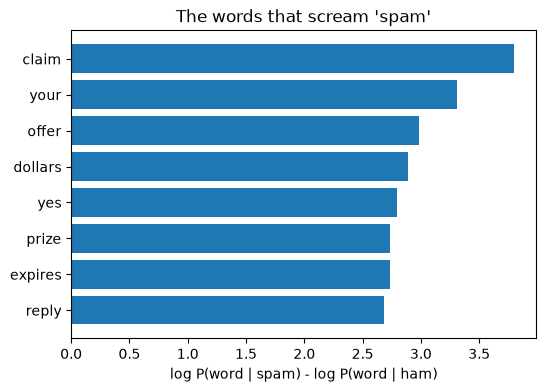

In [7]:
top = order[::-1][:8]
fig, ax = plt.subplots(figsize=(6, 4))
ax.barh([vocab[i] for i in top][::-1], [log_ratio[i] for i in top][::-1])
ax.set_xlabel("log P(word | spam) - log P(word | ham)")
ax.set_title("The words that scream 'spam'")
plt.show()

Now reproduce one verdict by hand. A class score is the log-prior plus, for each word in the message,
its count times that word's log-likelihood -- the concept note's "sum logs" rule:

In [8]:
msg = "free prize claim your cash now"
counts = vec.transform([msg]).toarray()[0]
log_scores = {}
for ci, c in enumerate(nb.classes_):
    log_scores[c] = nb.class_log_prior_[ci] + (counts * nb.feature_log_prob_[ci]).sum()
print("by-hand log-scores:", {str(c): round(float(log_scores[c]), 2) for c in nb.classes_})

logvec = np.array([log_scores[c] for c in nb.classes_])
posterior = np.exp(logvec - logvec.max())
posterior /= posterior.sum()
print("by-hand posterior :", {str(c): float(p) for c, p in zip(nb.classes_, np.round(posterior, 3))})
print("library  posterior:", {str(c): float(p) for c, p in zip(nb.classes_, np.round(nb.predict_proba(Xnew[[0]])[0], 3))})

by-hand log-scores: {'ham': -35.87, 'spam': -21.63}
by-hand posterior : {'ham': 0.0, 'spam': 1.0}
library  posterior: {'ham': 0.0, 'spam': 1.0}


~~~text
by-hand log-scores: {'ham': -35.87, 'spam': -21.63}
by-hand posterior : {'ham': 0.0, 'spam': 1.0}
library  posterior: {'ham': 0.0, 'spam': 1.0}
~~~

Our arithmetic matches the library exactly. Notice the posterior pins to **1.000** -- the spam score
($-21.63$) so far above the ham score ($-35.87$) that normalizing leaves nothing for ham. That extreme
confidence is the overconfidence the concept warned about: the *ranking* is right, but do not quote the
$1.000$ as a calibrated probability.

## Your Turn

### Exercise 1 -- Laplace smoothing rescues a class

Here is a spammy-sounding message that happens to mention **dinner** -- a word the spam half of the
training set never used. Without smoothing, that single unseen word gives $P(\text{dinner} \mid
\text{spam}) = 0$, which zeroes the entire spam score and vetoes the class. Add-one smoothing
(`alpha=1.0`, scikit-learn's default) gives every word a phantom count so no word can veto. Refit both
ways and watch the verdict flip.

**Hint:** fit `MultinomialNB(alpha=1e-10)` (almost no smoothing) and `MultinomialNB(alpha=1.0)` on `X_train, ytr`; for each, print `model.predict_proba(Xb)[0][spam_idx]` and `model.predict(Xb)[0]`.

In [9]:
borderline = "hey you won a free phone call now dinner"
Xb = vec.transform([borderline])

# Uncomment and complete the marked lines:
# nb_raw = MultinomialNB(alpha=1e-10).fit(X_train, ytr)    # almost no smoothing
# nb_smooth = MultinomialNB(alpha=1.0).fit(____, ____)     # add-one smoothing (the default)
# print(f"no smoothing  P(spam)={nb_raw.predict_proba(Xb)[0][spam_idx]:.3f} -> {nb_raw.predict(Xb)[0]}")
# print(f"add-one       P(spam)={nb_smooth.predict_proba(Xb)[0][spam_idx]:.3f} -> {nb_smooth.predict(Xb)[0]}")

<details><summary>Expected Output</summary>

~~~text
no smoothing  P(spam)=0.000 -> ham
add-one       P(spam)=0.965 -> spam
~~~

One unseen word, "dinner", dragged the no-smoothing model's $P(\text{spam})$ to exactly zero -- it
called an obvious spam message *ham*. Add-one smoothing restores a small likelihood for every word, the
spammy words ("won", "free", "claim"-adjacent) win again, and the message is correctly flagged. This is
why count-based Naive Bayes is never run without smoothing.
</details>

### Exercise 2 -- What "naive" costs

Text was the easy case -- disjoint vocabularies, perfect accuracy. The naive assumption shows its price
when features are **correlated**. Go back to L06's mango cultivars, whose length and weight move
together, and pit **Gaussian Naive Bayes** (a diagonal covariance -- it assumes the correlation away)
against L06's **LDA** (a full covariance -- it models the correlation). First rebuild the data:

In [10]:
rng_m = np.random.default_rng(7)         # fresh seed: the exact L06 mangoes
n = 90
len_m = rng_m.normal(10.5, 1.2, n)
len_k = rng_m.normal(12.0, 1.4, n)
mangoes = pd.DataFrame({
    "length_cm": np.concatenate([len_m, len_k]).round(2),
    "weight_g":  np.concatenate([410 + 10*(len_m - 10.5) + rng_m.normal(0, 70, n),
                                 560 + 10*(len_k - 12.0) + rng_m.normal(0, 70, n)]).round(0),
    "cultivar":  ["mayaguezano"] * n + ["keitt"] * n,
})
Xm = mangoes[["length_cm", "weight_g"]]
ym = mangoes["cultivar"]
Xm_train, Xm_test, ym_train, ym_test = train_test_split(Xm, ym, test_size=0.25,
                                                        random_state=7, stratify=ym)
print(len(Xm_train), "train /", len(Xm_test), "test mangoes")

135 train / 45 test mangoes


~~~text
135 train / 45 test mangoes
~~~

**Hint:** fit `GaussianNB()` and `LinearDiscriminantAnalysis()` on `Xm_train, ym_train`, then score each on `Xm_test, ym_test` with `.score(...)`.

In [11]:
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Uncomment and complete the marked lines:
# gnb = GaussianNB().fit(Xm_train, ym_train)            # naive: diagonal covariance
# lda = LinearDiscriminantAnalysis().fit(____, ____)    # L06: full covariance
# print(f"GaussianNB (diagonal):        {gnb.score(Xm_test, ym_test):.3f}")
# print(f"LDA        (full covariance): {lda.score(____, ____):.3f}")

<details><summary>Expected Output</summary>

~~~text
GaussianNB (diagonal):        0.911
LDA        (full covariance): 0.933
~~~

Two points of accuracy, bought by modeling the length-weight correlation that Naive Bayes throws away.
That is the whole trade in one number: **Naive Bayes is GDA with the off-diagonal covariance erased** --
cheaper, faster, and great when features really are roughly independent (text), but it leaves a little
accuracy on the table when they are not.
</details>

## Summary

- **Bag of words** turns documents into word-count vectors -- one feature per vocabulary word -- and the
  feature count explodes immediately (128 words here), which is exactly why the independence assumption
  is non-negotiable for text.
- **MultinomialNB** trained by counting alone and labeled every test message correctly; spam and chat
  use nearly disjoint vocabularies, the reason Naive Bayes ruled spam filtering.
- The model is fully inspectable: `feature_log_prob_` ranks the words, and a verdict is just a log-prior
  plus a sum of per-word log-likelihoods -- which we reproduced by hand to match the library.
- **Laplace smoothing** is mandatory with counts: one unseen word ("dinner") vetoed the spam class to
  zero until add-one smoothing restored it and flipped the verdict back to spam.
- On correlated features, the naive assumption costs accuracy: GaussianNB 0.911 vs LDA's 0.933 on the
  mangoes -- Naive Bayes is GDA with a diagonal covariance.
- Next (L08): **Support Vector Machines** close the unit -- a discriminative classifier that draws the
  *widest* margin between the classes, and bends straight boundaries into curved ones with the kernel
  trick.